Librerías y Funciones propias:

In [33]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

import numpy as np
import matplotlib.pyplot as plt
from helpers.overlapSave import overlapSaveBlock
from helpers.adapt import adapt
from helpers.room import room
from helpers.generateRirs import generateRirs

Simulation:

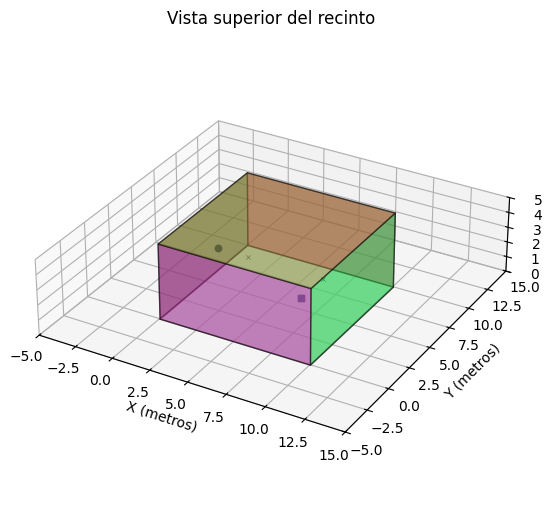

In [34]:
fs = 48000
room = room(fs)


Obtain RIRs:

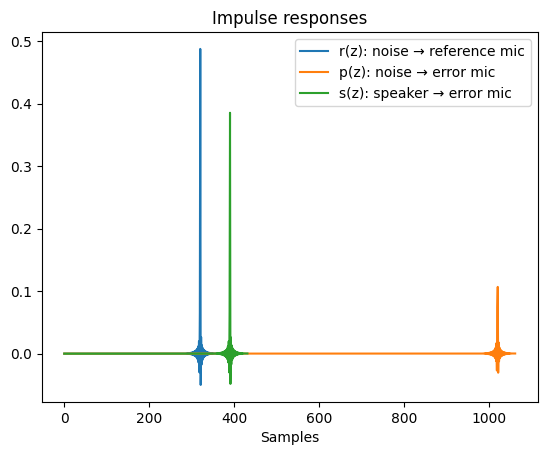

Delay R: 6.666666666666667 ms
Delay P: 21.25 ms
Delay S: 8.125 ms
In order to comply with causality, computational time must be smaller than: 6.458333333333332 ms
Reference path length:  362
Primary path length:  1062
Secondary path length:  432


In [35]:
rir_r, rir_p, rir_s = generateRirs(fs, room)

SPM: 

This implementation looks to first identify the secondary path without the controller activated, and then adapts the controller

The controller was activated in block number: 20


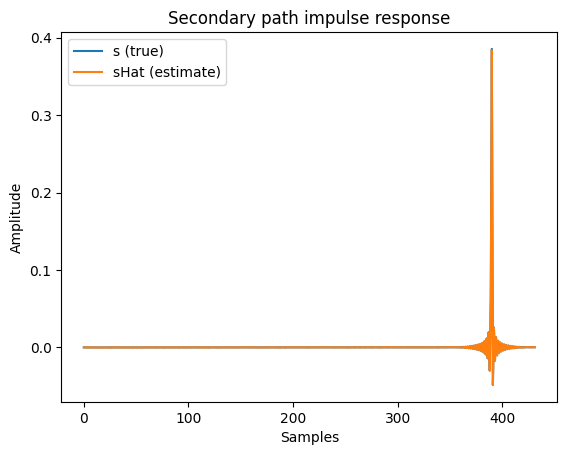

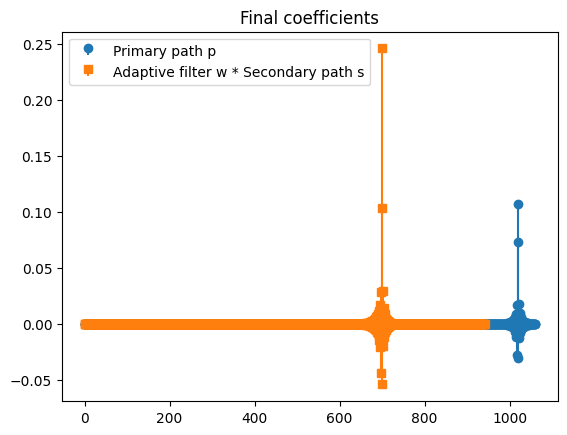

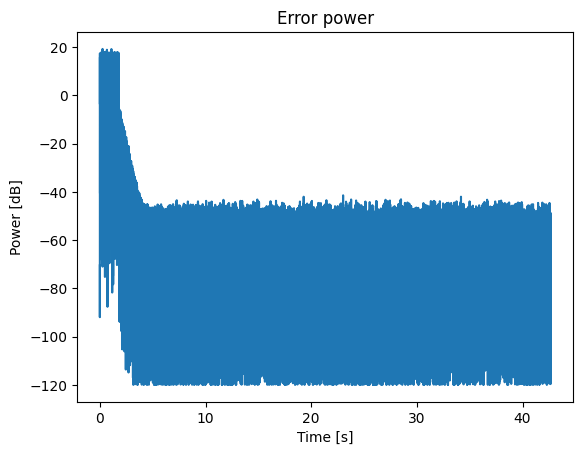

In [36]:
np.random.seed(0)

# Block and signal definition
blocklength = 4096
nBlocks = 500
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.random.randn(N)

# Identification noise initilization
identificationNoise = 5 * np.random.randn(N)

# Adaptive filter initialization (its spectrum has to be recalculated inside the loop)
mu = 5
M_w = 512
w = np.zeros(M_w)
N_w = blocklength + M_w - 1
wBuffer = np.zeros(M_w - 1)
wOutputBlocks = []

# Primary path
p = rir_p
M_p = len(p)
N_p = blocklength + M_p - 1
pSpectrum = np.fft.rfft(p, N_p)
pBuffer = np.zeros(M_p - 1)
pOutputBlocks = []

# Secondary path
s = rir_s 
M_s = len(s)
N_s = blocklength + M_s - 1
sSpectrum = np.fft.rfft(s, N_s)
sBuffer = np.zeros(M_s - 1)
sOutputBlocks = []

# Secondary path aproximation
sHat = np.zeros_like(s)
M_sHat = len(sHat)
N_sHat = blocklength + M_sHat - 1
sHatSpectrum = np.fft.rfft(sHat, N_sHat)
sHatBuffer = np.zeros(M_sHat - 1)
sHatOutputBlocks = []

sHatBufferPlantId = np.zeros(M_sHat - 1)
sHatOutputBlocksPlantId = []
muShat = 0.01

# Noise source path
r = rir_r
M_r = len(r)
N_r = blocklength + M_r - 1
rSpectrum = np.fft.rfft(r, N_r)
rBuffer = np.zeros(M_r - 1)
rOutputBlocks = []

# Scalar value to nullify the controller initially
activateController = 0
threshold = 0.03
thresholdWindow = 10

# History
e_hist = np.zeros(N)
mean_e_p_hist = np.zeros(nBlocks)
w_hist = np.zeros((N, M_w))
sHat_hist = np.zeros((N, M_sHat))

for k in range(nBlocks):
    # Block samples of X
    xBlock = x[k*blocklength : (k+1)*blocklength]

    # Reference mic signal
    rBlockOutput, rBuffer = overlapSaveBlock(xBlock, rSpectrum, rBuffer, M_r, N_r)
    rBlockOutput *= activateController
    rOutputBlocks.append(rBlockOutput)

    # Primary path P(z) (desired signal cannot be turned off for obvious reasons)
    pBlockOutput, pBuffer = overlapSaveBlock(xBlock, pSpectrum, pBuffer, M_p, N_p)
    pOutputBlocks.append(pBlockOutput)

    # Adaptive filter W(z)
    wSpectrum = np.fft.rfft(w, N_w)
    yBlockOutput, wBuffer = overlapSaveBlock(rBlockOutput, wSpectrum, wBuffer, M_w, N_w)
    wOutputBlocks.append(yBlockOutput)
    
    # Identification noise inyection
    identificationNoiseBlock = identificationNoise[k*blocklength : (k+1)*blocklength]
    uBlock = yBlockOutput + identificationNoiseBlock
    
    # Secondary path S(z)
    fuBlockOutput, sBuffer = overlapSaveBlock(uBlock, sSpectrum, sBuffer, M_s, N_s)
    sOutputBlocks.append(fuBlockOutput)

    if activateController == 0:
        # Error signal
        e = fuBlockOutput - pBlockOutput

        # Adapt secondary path model Shat(z)
        ypBlockOutput, sHatBufferPlantId = overlapSaveBlock(identificationNoiseBlock, sHatSpectrum, sHatBufferPlantId, M_sHat, N_sHat)
        sHatOutputBlocksPlantId.append(ypBlockOutput)
        
        ep = e - ypBlockOutput
        sHat = adapt(identificationNoiseBlock, ep, M_sHat, blocklength, sHat, muShat)
        sHatSpectrum = np.fft.rfft(sHat, N_sHat)
        
        ep_power = np.mean(ep**2)
        mean_e_p_hist[k] = ep_power

    else:
        e = pBlockOutput - fuBlockOutput

    # Filtered X
    fxBlockOutput, sHatBuffer = overlapSaveBlock(rBlockOutput, sHatSpectrum, sHatBuffer, M_sHat, N_sHat)
    sHatOutputBlocks.append(fxBlockOutput)

    # LMS algorithm
    w = adapt(fxBlockOutput, e, M_w, blocklength, w, mu)

    # Calculate difference between secondary path and the model
    if k > thresholdWindow and np.mean(mean_e_p_hist[k-thresholdWindow:k]) < threshold and activateController == 0:
         # Activate controller
         activateController = 1
         print("The controller was activated in block number:", k)

         # Deactivate identifying noise
         identificationNoise = np.zeros(N)


    # History
    e_hist[k * blocklength:(k+1) * blocklength] = e
    w_hist[k * blocklength:(k+1) * blocklength, :] = w
    sHat_hist[k * blocklength:(k+1) * blocklength, :] = sHat

#print(mean_e_p_hist[-1])

plt.figure()
plt.plot(s, label='s (true)')
plt.plot(sHat, label='sHat (estimate)')
plt.legend()
plt.title('Secondary path impulse response')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

plt.figure()
plt.stem(p, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.stem(np.convolve(w, s)[:len(p)], linefmt='C1-', markerfmt='C1s', basefmt=" ")
plt.legend(['Primary path p', 'Adaptive filter w * Secondary path s'])
plt.title('Final coefficients')
plt.show()

plt.figure()
plt.plot(t, 10*np.log10(e_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

# plt.figure()
# for k in range(M_w):
#     plt.plot(t, w_hist[:, k])
# plt.title('Coefficient convergence')
# plt.xlabel('Time [s]')
# plt.ylabel('Value')
# plt.show()


Identification noise of higher amplitudes allow the system to converge to better secondary paths models since the steady state depends on the relation between identifying noise power and desired signal power. However, higher amplitudes decrease the maximun convergence coefficient allowed, leading to slower convergence times.

